Para nuevos usuariso de colab, para conectar con su disco de drive. Ejecutar sólo la primera vez.

In [ ]:
#from google.colab import drive
#drive.mount('/content/gdrive')

La celda devuelve lo siguiente:
<figure>
<center>
<img src='https://drive.google.com/thumbnail?id=1FjfwBMl6uE4ouU4WBEJ-2mqBw6eIfa7P'/>
</figure>

Haga clic en el enlace, dé acceso a Google Colab a su unidad y copie el código de autorización. Pégelo y listo. Ahora puede acceder a sus archivos de Google Drive en.

/content/drive/My Drive/

Use el panel de la izquierda para bnavegar en la unidad.

Para poder utilizar las librerías de python, debíes enerlas en drive. Una vez que las tengáis en drive, debíes ejecutar el siguiente código:

In [ ]:
import os
import sys
# Modules_Path = "/content/drive/MyDrive/ASIGNATURAS/TDI/Prácticas"  # sustituid esto por la ubicación de vuestras librerías
# sys.path.insert(0, os.path.abspath(Modules_Path))

# Práctica 3.1
En esta práctica abordaremos el problema de la detección de señales en entornos de hipótesis binaria. Comenzaremos con la formulación teórica del porblema, y posteriormente lo resolveremos para los casos de una constante inmersa en ruido para una sóla muestra, para $N$ muestras y para formas de onda.

Nos piden detectar un nivel constante $A$ en presencia de ruido gausiano, de media $\mu=0$ y varianza $σ^2$. Recuerde que en el caso de ruidos gaussianos, la varianza es la potencia media de ruido. En este caso habrá dos hipótesis: $H_0$, solo ruido, y $H_1$, constante $A$ y ruido

\begin{equation}
 H_0 : x = w\\
 H_1 : x = A + w
 \tag{1}
\end{equation}

donde $x$ es la observación, $A$ una constante y $w \sim N(0,σ^2)$.

Vamos a comenzar el código importando librerías:


In [ ]:
from scipy import signal
from scipy import stats
import numpy as np
import matplotlib.pylab as plt
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

A continuación, definimos las variables y constantes del problema según el enunciado. Podemos cambiarlas en cualquier momento para comprobar su efecto:

In [ ]:
A = 1 # Constant amplitude
PH1 = 1/2 # probability of hypothesis 1
PH0 = 1/2 # probability of hypothesis 0
PFA = 0.1 # probability of false alarm for Neyman-Pearson
NoisePower = 0.25 # Noise power (variance)
NoiseMean = 0  # Mean of Gaussian Noise

Bajo la hipótesis $H_0$, las observaciones son sólo ruido, luego se comportan como una gausiana de media cero y varianza $σ^2$. Bajo la hipótesis $H_1$, como una gausiana de media $\mu=A$, puesto que $A$ es una constante que se suma al ruido, cn lo que desplaza la media hacia $A$. Puesto que $A$ es constante, la varianza sigue siendo $σ^2$.

\begin{equation}
 p(x|H_0) \sim N(0,σ^2) \\
 p(x|H_1) \sim N(A,σ^2)
 \tag{2}
\end{equation}

Según el criterio de Neyman-Pearson, la máxima probabilidad de detección $P_D$ la obtenemos decidiendo entre las hipótesis $H_1$ y $H_0$ comparando el cociente de verosimilitudes con un umbral $\gamma$ de forma que:

\begin{equation}
 L(x)=\frac{p(x|H_1)}{p(x|H_0)} \overset{H_1}{\underset{H_0}{\lessgtr}} \gamma
 \tag{3}
\end{equation}

fijando $\gamma$ para una $P_{FA}$ dada.

Teniendo en cuenta que la función de densidad de probabilidad $p(x)$ de una Gaussiana $N(\mu, \sigma^2)$ es:

\begin{equation}
  p(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}
 \tag{4}
 \end{equation}

Si sustituimos (4) en (2) para las diferentes hipótesis

\begin{equation}
 p(x|H_0) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{x^2}{2\sigma^2}}
 \\
 p(x|H_1) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-A)^2}{2\sigma^2}}
 \tag{5}
 \end{equation}

Y usando (5) en (3):

\begin{equation}
 \frac{\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-A)^2}{2\sigma^2}}}{\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{x^2}{2\sigma^2}}}
 \tag{6}
\end{equation}

Y simplificando la expresión

\begin{equation}
e^{-\frac{1}{2\sigma^2} \cdot \big((x-A)^2-x^2\big)}\overset{H_1}{\underset{H_0}{\lessgtr}} \gamma
 \tag{7}
\end{equation}

Si aplicamos logaritmos en ambos lados:

\begin{equation}
-\frac{1}{2\sigma^2} \cdot \big((x-A)^2-x^2\big) \overset{H_1}{\underset{H_0}{\lessgtr}} \ln\gamma
 \tag{8}
\end{equation}

Y finalmente, despejando para $x$ obtenemos:

\begin{equation}
  x \overset{H_1}{\underset{H_0}{\lessgtr}} \eta = \frac{2\sigma^2\ln\gamma}{A} + \frac{A}{2}
 \tag{9}
\end{equation}

El problema se reduce a comparar un estadístico suficiente $T(x)$ con un umbral $\eta$. En este caso particular el estadístico suficiente $T(x)=x$, y el umbral $\eta$ el que aparece a la derecha de la inecuación en (9). La máxima probabilidad de detección $P_D$ la obtendremos con un umbral $\eta$ fijado para una $P_{FA}$ determinada, calculando ambas probabilidades con las funciciones de densidad de probabilidad del estadístico $T(x)$ bajos las hipótesis $H_0$ y $H_1$.

Vamos ahora a crear las funciones de densidad de probabilidad (pdf) de las dos hipótesis para poder representarlas, y utilizarlas luego para generar ejemplos. Para ello podemos utilizar las herramientas de la toolbox *scipy.stats* que nos permiten crear distribuciones estadísticas como objetos.


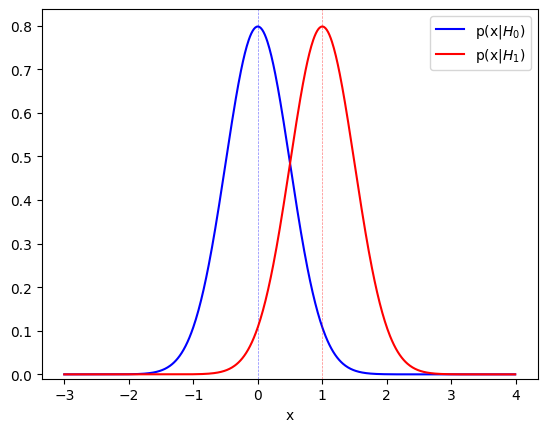

In [ ]:
NoisePower = 0.25
Mean_H0= 0  # mean under H0
Std_H0 = np.sqrt(NoisePower)  # std under H0
Mean_H1= A # mean under H1
Std_H1 = np.sqrt(NoisePower)  # std under H1
x_values = np.arange(Mean_H0-6*Std_H0, Mean_H1+6*Std_H1, 0.01)  # creates axis for observations using 6 times the span of the gaussians
pdf_H0 = stats.norm(Mean_H0, Std_H0) # create distribution for H0
pdf_H1 = stats.norm(Mean_H1, Std_H1) # create distribution for H1

plt.plot(x_values, pdf_H0.pdf(x_values), color='blue', label='p(x|$H_0$)')
plt.axvline(x=Mean_H0, color='blue', linestyle='--', linewidth=0.5, alpha=0.5)
plt.plot(x_values, pdf_H1.pdf(x_values), color='red', label='p(x|$H_1$)')
plt.axvline(x=Mean_H1, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
plt.ylim(bottom=-0.01)
plt.xlabel('x')
plt.legend()

Según lo anterior, la $P_{FA}$ es la probabilidad de que el estadístico supere el umbral de detección, bajo la hipótesis 0 (no hay señal). La pdf de esta probablidad es la de la observación con solo ruido. En este caso particular, según (9) el estadístico coincide con la observación, luego su pdf también, por lo que:

\begin{equation}
P_{FA} = \int_{\eta}^{\infty}p(x|H_0)\partial x
 \tag{10}
\end{equation}

Debemos despejar $\eta$ en la expresión anterior, y una vez calculada utilizarla para calcular la $P_D$, que será la probabilidad de superar el umbral $\eta$ bajo la hipótesis 1, es decir:

\begin{equation}
P_D = \int_{\eta}^{\infty}p(x|H_1)\partial x
 \tag{11}
\end{equation}

Para calcular el umbral deberíamos usar las funciones Q, pero podemos aprovechar las librerías stats que proporcionan todos los valores que necesitamos de las funciones de densidad de probabilidad anteriormente creadas, tal y como se muestra en el siguiente código.

In [ ]:
Pfa_NP = PFA # viene dada por el enunciado
Th = pdf_H0.ppf(1-Pfa_NP)  # calculo umbral bajo hipótesis H0
Pd = 1-pdf_H1.cdf(Th)  # calculo umbral bajo hipótesis H1
print('Bajo el criterio de Nayman Pearson las prestaciones del detector para los valores de A y Noisepower dados son')
print('Pfa = {}'.format(Pfa_NP))
print('Umbral = {}'.format(Th))
print('Pd = {}'.format(Pd))

Bajo el criterio de Nayman Pearson las prestaciones del detector para los valores de A y Noisepower dados son
Pfa = 0.1
Umbral = 0.6407757827723002
Pd = 0.7637595841058832


Con estos valores, podemos representar en las pdf cómo se distribuyen las probabilidades, así como la posición del umbral.

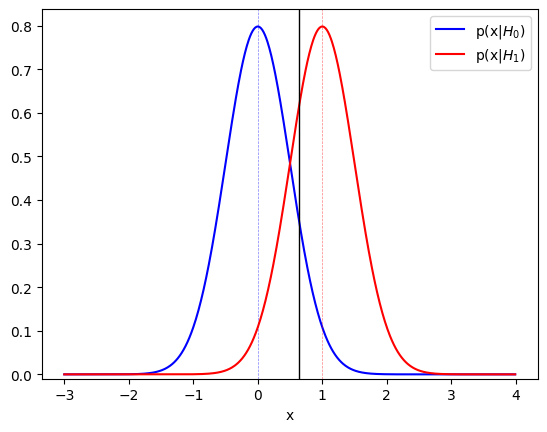

In [ ]:
#Representamos pdf
plt.plot(x_values, pdf_H0.pdf(x_values), color='blue', label='p(x|$H_0$)')
plt.axvline(x=Mean_H0, color='blue', linestyle='--', linewidth=0.5, alpha=0.5)
plt.plot(x_values, pdf_H1.pdf(x_values), color='red', label='p(x|$H_1$)')
plt.axvline(x=Mean_H1, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
plt.ylim(bottom=-0.01)
plt.xlabel('x')
plt.legend()
# representamos umbral
plt.axvline(x=Th, color='black', linewidth=1)

Para analizar el comportamiento del detector, debemos representar la $P_D$ en función de todos los posiobles valores de la $P_{FA}$. De esta forma representaremos lo que se conoce como curvas *Receiver Operating Characteristics* (ROC).

Para una mejor comprensión de la dependencia entre los diferentes parámetros del detector, vamos a repetir los calculos dejando variable de forma interactiva la relación señal a ruido ($SNR$). Recuerde que la $SNR$ sería la relación entre la potencia (o energía) de la señal y la del ruido. En ese caso, la señal es una constante de valor $A$, y la potencia del ruido es $\sigma^2$:

\begin{equation}
SNR = \frac{A^2}{\sigma^2}
 \tag{12}
\end{equation}

Si fijamos $A=1$, podemos explorar el comportamiento del detector sin más que variar la potencia de ruido, esto es $\sigma^2$. En el siguiente código se generan unas interfaces que permiten al usuario modificar la $P_{FA}$ deseada y la $SNR$.

Output()

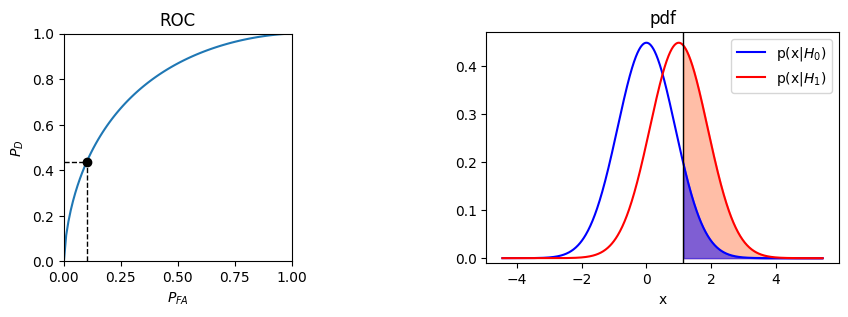

In [ ]:
# inicializamos vectores
Pfa_NP = np.arange(0,1,0.01)  # vector con valores de PFA
Pd_NP = np.zeros_like(Pfa_NP)  #  vector con valores PD
# Fix signal constant amplitude
A = 1

w_PFA = widgets.FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01,
                         description='PFA:', disabled=False,
                         continuous_update=False)

w_SNR = widgets.BoundedFloatText(value=1, min=0, max=20, step=1,
                         description='SNR (dB):', disabled=False,
                         continuous_update=False)

def plotROCpdf(SNRdB, PFA):
  SNR = 10**(SNRdB/10)
  NoisePower = A**2/SNR # noise power
  Std_H0 = np.sqrt(NoisePower)
  Std_H1 = np.sqrt(NoisePower)
  pdf_H0 = stats.norm(Mean_H0, Std_H0)
  pdf_H1 = stats.norm(Mean_H1, Std_H1)
  x_values = np.arange(Mean_H0-5*Std_H0, Mean_H1+5*Std_H1, 0.01)  # creates axis for observations using 5 times the span of the gaussians
  # Calculate threshold and PD for the specified PFA
  TH = pdf_H0.ppf(1-PFA)
  PD = 1-pdf_H1.cdf(TH)
  print('Para una PFA={:.3f} y NoisePower={:.3f}, el umbral es TH={:.3f}, y la PD={:.3f}'.format(PFA,NoisePower,TH,PD))
  # calcula Th y Pd para todos los valores de Pfa para dibujar ROC
  for i in np.arange(len(Pfa_NP)):
    Th = pdf_H0.ppf(1-Pfa_NP[i])
    Pd_NP[i] = 1-pdf_H1.cdf(Th)

  fig = plt.figure(figsize=[10, 3])
  ax1 = fig.add_subplot(131)
  ax1.plot(Pfa_NP, Pd_NP, label='$\sigma^2$={}'.format(NoisePower))
  ax1.axvline(x=PFA, ymin=0, ymax=PD, color='black', linestyle='--', linewidth=1)
  ax1.axhline(y=PD, xmin=0, xmax=PFA, color='black', linestyle='--', linewidth=1)
  ax1.plot(PFA, PD, color='black', marker='o')
  ax1.set_ylim([0, 1])
  ax1.set_xlim([-0.001, 1])
  ax1.set_aspect('equal', 'box')
  ax1.set_xlabel('$P_{FA}$')
  ax1.set_ylabel('$P_{D}$')
  ax1.set_title('ROC')

  ax2 = fig.add_subplot(122)
  # plot pdf
  ax2.plot(x_values, pdf_H0.pdf(x_values), color='blue', label='p(x|$H_0$)')
  ax2.plot(x_values, pdf_H1.pdf(x_values), color='red', label='p(x|$H_1$)')
  # fill area under pdf beyond selected PFA
  x_tofill = np.arange(TH, x_values[-1], 0.01)
  ax2.fill_between(x_tofill,  pdf_H1.pdf(x_tofill), y2=0, color='coral', alpha=0.5)
  ax2.fill_between(x_tofill,  pdf_H0.pdf(x_tofill), y2=0, color='blue', alpha=0.5)
  # plot vertical line at TH
  ax2.axvline(x=TH, color='black', linewidth=1)
  ax2.set_ylim(bottom=-0.01)
  ax2.set_xlabel('x')
  ax2.set_title('pdf')
  ax2.legend(loc='upper right')

  fig.canvas.draw()

ui = widgets.HBox([w_SNR, w_PFA])
out = widgets.interactive_output(plotROCpdf, {'SNRdB':w_SNR, 'PFA':w_PFA})
display(ui, out)


Para mayor claridad de la influencia de la $SNR$, o lo que es lo mismo, diferentes potencias de ruido, vamos a representar juntas varias ROC para diferentes valores de $SNR$.

Text(0, 0.5, '$P_{D}$')

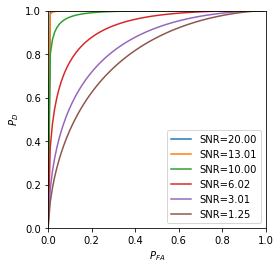

In [ ]:
Pfa_NP = np.arange(0,1,0.01)
Pd_NP = np.zeros_like(Pfa_NP)
NoisePower = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75]
fig = plt.figure()
ax = fig.add_subplot(111)
for j in np.arange(len(NoisePower)):
  SNR = 10*np.log10(A**2/NoisePower[j])
  for i in np.arange(len(Pfa_NP)):
    Th = stats.norm.ppf(1-Pfa_NP[i], loc=0, scale=np.sqrt(NoisePower[j]))
    Pd_NP[i] = 1-stats.norm.cdf(Th, loc=A, scale=np.sqrt(NoisePower[j]))
  ax.plot(Pfa_NP, Pd_NP, label='SNR={:.2f}'.format(SNR))
ax.legend()
ax.set_ylim([0, 1])
ax.set_xlim([-0.001, 1])
ax.set_aspect('equal', 'box')
ax.set_xlabel('$P_{FA}$')
ax.set_ylabel('$P_{D}$')

Aquí os pongo un ejemplo de como comprobar el funcionamiento del detector. El ejemplo a continuación es para el criterio Neyman-Pearson. Puede probar con diferentes niveles de ruido.

Se incluye en el ejemplo un estudio experimental según el método de [Montecarlo](https://en.wikipedia.org/wiki/Monte_Carlo_method) para comprobar si los valores teóricos coinciden con los experimentales.


Ejemplo de funcionamiento del detector según Neyan-Pearson
para un valor constante A inmerso en ruido Gaussiano de media 0.
Potencia de ruido (varianza) = 0.100
Constante A = 1.000
Pfa = 0.100
Umbral = 0.405
Pd = 0.970
Para el estudio experimental por el método de Montecarlo realizamos 20000000 pruebas.
Se han realizado 10000000 bajo cada hipótesis, con el siguiente resultado:
Ha habido 999803 falsas alarmas. PFA experimental=0.100
Ha habido 9700328 detecciones correctas. PD experimental=0.970
Ha habido 299672 fallos de detección. PMISS experimental=0.030
Total erróneas 1299475. Pe experimental=0.065.


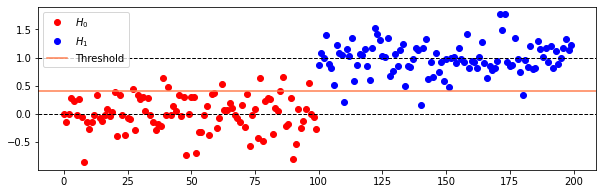

In [ ]:
# Fijamos los parámetros del modelo
NoisePower = 0.1
A = 1
Pfa_NP = 0.1
# creamos pdf
Mean_H0 = 0
Mean_H1 = A
Std_H0 = np.sqrt(NoisePower)
Std_H1 = np.sqrt(NoisePower)
pdf_H0 = stats.norm(Mean_H0, Std_H0)
pdf_H1 = stats.norm(Mean_H1, Std_H1)

# caluclamos umbral y Pd
Th = pdf_H0.ppf(1-Pfa_NP)  # calculo umbral bajo hipótesis H0
Pd = 1-pdf_H1.cdf(Th)  # calculo Pd bajo hipótesis H1

# Vamos a hacer N>100 observaciones aleatorias en cada hipótesis
# El número debe ser lo suficientemente alto para que sea un expermiento significativo
NExp = 10000000  # número de veces que repetimos cada experimento (para cada hipótesis)
x_H0 = pdf_H0.rvs(size=NExp)  # genera muestras solo ruido según pH0
x_H1 = pdf_H1.rvs(size=NExp)  # genera muestras según pH1 señal y ruido
NFA = np.where(x_H0 >= Th)  # número de falsas alarmas H1|H0
NMISS = np.where(x_H1 < Th) # número de Miss H0|H1
ND = np.where(x_H1 >= Th)  # número de detecciones correctas bajo H1

print('Ejemplo de funcionamiento del detector según Neyan-Pearson')
print('para un valor constante A inmerso en ruido Gaussiano de media 0.')
print('Potencia de ruido (varianza) = {:.3f}'.format(NoisePower))
print('Constante A = {:.3f}'.format(A))
print('Pfa = {:.3f}'.format(Pfa_NP))
print('Umbral = {:.3f}'.format(Th))
print('Pd = {:.3f}'.format(Pd))
print('Para el estudio experimental por el método de Montecarlo realizamos {} pruebas.'.format(2*NExp))
print('Se han realizado {} bajo cada hipótesis, con el siguiente resultado:'.format(NExp))
print('Ha habido {} falsas alarmas. PFA experimental={:.3f}'.format(len(NFA[0]), len(NFA[0])/NExp))
print('Ha habido {} detecciones correctas. PD experimental={:.3f}'.format(len(ND[0]), len(ND[0])/NExp))
print('Ha habido {} fallos de detección. PMISS experimental={:.3f}'.format(len(NMISS[0]), len(NMISS[0])/NExp))
print('Total erróneas {}. Pe experimental={:.3f}.'.format(len(NMISS[0])+len(NFA[0]), (len(NMISS[0])+len(NFA[0]))/(2*NExp) ))
fig = plt.figure(clear=True, figsize=[10, 3])
ax = fig.add_subplot(111)
x_Axis = np.arange(200)
ax.plot(x_Axis[0:100], x_H0[0:100], 'ro', label='$H_0$') # plot point for H0
ax.plot(x_Axis[100:200], x_H1[0:100],'bo', label='$H_1$') # plot point for H1
ax.axhline(y=Th, color='coral', label='Threshold')
ax.axhline(y=A, color='k', linestyle='--', linewidth=1)
ax.axhline(y=0, color='k', linestyle='--', linewidth=1)
ax.legend()


A continuación trataremos el problema en el caso de utilizar $N$ muestras en la observación. En este caso, las hipótesis $H_0$, solo ruido, y $H_1$, constante $A$ y ruido, quedarían como sigue:

\begin{equation}
 H_0 : \underline{x}= \underline{w}\\
 H_1 : \underline{x}= A + \underline{w}
 \tag{13}
\end{equation}

donde $\underline{x}=$ es el vector de $N$ observaciones y $\underline{w}=$ un vector de $N$ muestras de ruido blanco i.i.d.:

\begin{equation}
 \underline{x}=x[n] = \big[x[0], x[1], ..., x[N-1]\big]^T\\
 \underline{w}=w[n] = \big[w[0], w[1], ..., w[N-1]\big]^T\\
 \tag{14}
\end{equation}

Donde cada $w[n]$ sigue una distribución $N(0,\sigma^2)$.

Si rescribimos el cociente de verosimilitudes de (3) pero teniendo en cuenta las nuevas condiciones:

\begin{equation}
 L(x)=\frac{p(\underline{x}|H_1)}{p(\underline{x}|H_0)} \overset{H_1}{\underset{H_0}{\lessgtr}} \gamma
 \tag{15}
\end{equation}

Con lo que ahora deberemos calcular las funciones de densidad de probabilidad $p(\underline{x}|H_0)$ y $p(\underline{x}|H_1)$. Debemos tener en cuenta que las muestras de ruido son i.i.d., con lo que la función de densidad conjunta para todos los leemntos del vector será igual al producto de las funciones de densidad de probaiblidad de cada elemento, esto es:

\begin{equation}
 p(\underline{x}|H_0)= \prod_{n=0}^{N-1} p(x[n]|H_0)   \\
 p(\underline{x}|H_1)= \prod_{n=0}^{N-1} p(x[n]|H_1)
 \tag{16}
\end{equation}

Y asumiendo (2) y (5), quedaría:

\begin{equation}
 p(\underline{x}|H_0)= \prod_{n=0}^{N-1} \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{x[n]^2}{2\sigma^2}}=\frac{1}{(2\pi\sigma)^{N/2}}e^{-\frac{\sum_{n=0}^{N-1}x[n]^2}{2\sigma^2}}   \\
 p(\underline{x}|H_1)= \prod_{n=0}^{N-1} \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x[n]-A)^2}{2\sigma^2}}=\frac{1}{(2\pi\sigma)^{N/2}}e^{-\frac{\sum_{n=0}^{N-1}(x[n]-A)^2}{2\sigma^2}}
 \tag{17}
\end{equation}

Y usando (17) en (15):

\begin{equation}
 \frac{\frac{1}{(2\pi\sigma)^{N/2}}e^{-\frac{\sum_{n=0}^{N-1}(x[n]-A)^2}{2\sigma^2}}}{\frac{1}{(2\pi\sigma)^{N/2}}e^{-\frac{\sum_{n=0}^{N-1}x[n]^2}{2\sigma^2}}}=e^{-\frac{1}{2\sigma^2} \cdot \big(\sum_{n=0}^{N-1}(x[n]-A)^2-\sum_{n=0}^{N-1}x[n]^2\big)}
 \tag{18}
\end{equation}

Y simplificando la expresión:

\begin{equation}
e^{-\frac{1}{2\sigma^2} \cdot \big(\sum_{n=0}^{N-1}(-2Ax[n]+A^2)\big)}\overset{H_1}{\underset{H_0}{\lessgtr}} \gamma
 \tag{19}
\end{equation}

Si aplicamos logaritmos en ambos lados:

\begin{equation}
-\frac{1}{2\sigma^2} \cdot \sum_{n=0}^{N-1}\big(-2Ax[n]+A^2\big) \overset{H_1}{\underset{H_0}{\lessgtr}} \ln\gamma
 \tag{20}
\end{equation}

Y finalmente, despejando para $x[n]$ obtenemos:

\begin{equation}
  \frac{1}{N}\sum_{n=0}^{N-1}x[n] \overset{H_1}{\underset{H_0}{\lessgtr}} \eta = \frac{2\sigma^2\ln\gamma}{NA} + \frac{A}{2}
 \tag{21}
\end{equation}

El problema se reduce a comparar un estadístico suficiente $T(x)$ con un umbral $\eta$. La máxima probabilidad de detección $P_D$ la obtendremos con un umbral $\eta$ fijado para una $P_{FA}$ determinada, calculando ambas probabilidades con las funciciones de densidad de probabilidad del estadístico $T(x)$ bajos las hipótesis $H_0$ y $H_1$. Podemos reescribir (13) utilizando el estadístico suficiente $$

\begin{equation}
 H_0 : T(x)=\frac{1}{N}\sum_{n=0}^{N-1}x[n]=\frac{1}{N}\sum_{n=0}^{N-1}w[n] \\
 H_1 : T(x)=\frac{1}{N}\sum_{n=0}^{N-1}x[n]=\frac{1}{N}\sum_{n=0}^{N-1}(A+w[n])=A+\frac{1}{N}\sum_{n=0}^{N-1}w[n]
 \tag{13}
\end{equation}

ES decir, que bajo la hipótesis $H_0$, $T(x)$ se comporta como el promedio de $N$ muestras de ruido blanco Gaussiano, que es una gausiana con la misma media, en este caso 0, y con varianza $\sigma_{T(X)|H_0}^2=\sigma^2/N$. Por otro lado, $H_1$, $T(x)$ se comporta como el promedio de $N$ muestras de ruido blanco Gaussiano de media A, y con varianza $\sigma_{T(X)|H_0}^2=\sigma^2/N$.

\begin{equation}
 p(T(x)|H_0) \sim N(0,σ^2/N) \\
 p(T(x)|H_1) \sim N(A,σ^2/N)
 \tag{22}
\end{equation}

Y las probabilidades $P_{FA}$ y $P_D$ quedarían:
\begin{equation}
P_{FA} = P(T(X)>\eta|H_0)= \int_{\eta}^{\infty}p(T(x)|H_0)\partial T(x) \\
P_{D} = P(T(X)>\eta|H_1) = \int_{\eta}^{\infty}p(T(x)|H_1)\partial T(x)
 \tag{23}
\end{equation}

Según el criterio de Neyman-Pearson, para una $P_{FA}$ dada, obtendremos la máxima debemos calcular el umbral $\eta$ despejando de (23), para lo que podemos usar, como hicimos antes, la función Q o las herrmaientas *ppf* de *stats*.

A continuación repetiremos los cálculos, comparando el comportamiento de los detectores para 1 punto y para $N$ puntos, dejando $N$ como variable a modificar por el usuario. Compruebe el efecto que el número de muestras usadas en el promedio tiene sobre el detector.

Output()

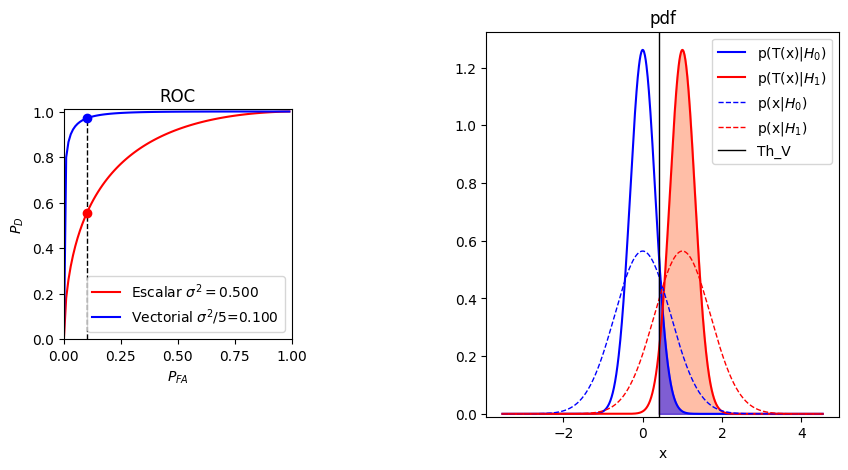

In [ ]:
# inicializamos vectores
Pfa_NP = np.arange(0,1,0.01)  # vector con valores de PFA
Pd_NP_V = np.zeros_like(Pfa_NP)  #  vector con valores PD en caso vector
Pd_NP = np.zeros_like(Pfa_NP)  #  vector con valores PD en caso escalar

# Fix signal constant amplitude
A = 1

w_N = widgets.IntSlider(value=5, min=2, max=20, step=1,
                         description='Nº muestras:', disabled=False,
                         continuous_update=False)

Mean_H0 = 0
Mean_H1 = A
NoisePower = 0.5 # noise power

#Caso escalar
Std_H0 = np.sqrt(NoisePower)
Std_H1 = np.sqrt(NoisePower)
pdf_H0 = stats.norm(Mean_H0, Std_H0)
pdf_H1 = stats.norm(Mean_H1, Std_H1)

def plotROCpdf(N):
  # caso vectorial
  Std_H0_V = np.sqrt(NoisePower/N)
  Std_H1_V = np.sqrt(NoisePower/N)
  pdf_H0_V = stats.norm(Mean_H0, Std_H0_V)
  pdf_H1_V = stats.norm(Mean_H1, Std_H1_V)

  x_values = np.arange(Mean_H0-5*Std_H0, Mean_H1+5*Std_H1, 0.01)  # creates axis for observations using 5 times the span of the gaussians
  # Calculate threshold and PD for the specified PFA
  TH = pdf_H0.ppf(1-PFA)
  PD = 1-pdf_H1.cdf(TH)
  TH_V = pdf_H0_V.ppf(1-PFA)
  PD_V = 1-pdf_H1_V.cdf(TH_V)
  print('Para una PFA={:.3f} y NoisePower={:.3f}'.format(PFA,NoisePower))
  print('Caso escalar: TH={:.3f}, y la PD={:.3f}'.format(TH,PD))
  print('Caso vectorial N={} muestras: TH={:.3f}, y la PD={:.3f}'.format(N,TH_V,PD_V))
  # calcula Th y Pd para todos los valores de Pfa para dibujar ROC
  for i in np.arange(len(Pfa_NP)):
    Th = pdf_H0.ppf(1-Pfa_NP[i])
    Pd_NP[i] = 1-pdf_H1.cdf(Th)

    Th_V = pdf_H0_V.ppf(1-Pfa_NP[i])
    Pd_NP_V[i] = 1-pdf_H1_V.cdf(Th_V)

  fig = plt.figure(figsize=[10, 5])
  ax1 = fig.add_subplot(131)
  ax1.plot(Pfa_NP, Pd_NP, color='red', label='Escalar $\sigma^2={:.3f}$'.format(NoisePower))
  ax1.plot(Pfa_NP, Pd_NP_V, color='blue', label='Vectorial $\sigma^2/{}$={:.3f}'.format(N, NoisePower/N))
  ax1.axvline(x=PFA, ymin=0, ymax=PD_V, color='black', linestyle='--', linewidth=1)
  ax1.plot(PFA, PD, color='red', marker='o')
  ax1.plot(PFA, PD_V, color='blue', marker='o')
  ax1.set_ylim([0, 1.01])
  ax1.set_xlim([-0.001, 1])
  ax1.set_aspect('equal', 'box')
  ax1.set_xlabel('$P_{FA}$')
  ax1.set_ylabel('$P_{D}$')
  ax1.set_title('ROC')
  ax1.legend(loc='lower right')
  ax2 = fig.add_subplot(122)
  # plot pdf
  ax2.plot(x_values, pdf_H0_V.pdf(x_values), color='blue', label='p(T(x)|$H_0$)')
  ax2.plot(x_values, pdf_H1_V.pdf(x_values), color='red', label='p(T(x)|$H_1$)')
  ax2.plot(x_values, pdf_H0.pdf(x_values), color='blue', linestyle='--', linewidth=1, label='p(x|$H_0$)')
  ax2.plot(x_values, pdf_H1.pdf(x_values), color='red', linestyle='--', linewidth=1, label='p(x|$H_1$)')
  # fill area under pdf beyond selected PFA
  x_tofill = np.arange(TH_V, x_values[-1], 0.01)
  ax2.fill_between(x_tofill,  pdf_H1_V.pdf(x_tofill), y2=0, color='coral', alpha=0.5)
  ax2.fill_between(x_tofill,  pdf_H0_V.pdf(x_tofill), y2=0, color='blue', alpha=0.5)
  # plot vertical line at TH
  ax2.axvline(x=TH_V, color='black', linewidth=1, label='Th_V')
  #ax2.axvline(x=TH, color='black', linewidth=1, linestyle='--', label='Th')
  ax2.set_ylim(bottom=-0.01)
  ax2.set_xlabel('x')
  ax2.set_title('pdf')
  ax2.legend(loc='upper right')

  fig.canvas.draw()

ui = widgets.HBox([w_N])
out = widgets.interactive_output(plotROCpdf, {'N':w_N})
display(ui, out)

# Ejemplo de generación de forma de onda. Forma de onda gaussiana.
Programe un detector de forma de onda siguiendo la misma pauta que en los desarrollos anteriores, calculando y representando ROC's, pdf, probabilidades, ejemplos, etc. En el código siguiente tiene un generador de la forma de onda, incluyendo el ruido aditivo.

Text(0.5, 0, 'H1 (signal + noise)')

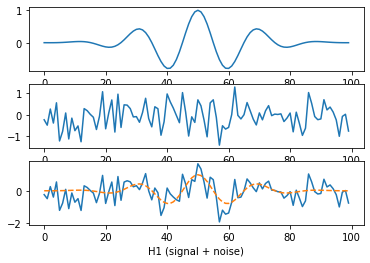

In [ ]:
t = np.linspace(-1, 1, 2 * 50, endpoint=False)  # crea eje de tiempo para crear la señal
s = signal.gausspulse(t, fc=2.5)  # crea señal tipo pulso gaisiano (sinuoside ponderada por gausiana)

N = len(t)
NoisePower = 0.5
w =  np.random.normal(0, NoisePower, N)
x0 = w
x1 = s+w
fig = plt.figure(clear=True)
ax1 = fig.add_subplot(311)
ax1.plot(s)
ax1.set_xlabel('Signal')
ax2 = fig.add_subplot(312)
ax2.plot(x0)
ax2.set_xlabel('H0 (only noise)')
ax3 = fig.add_subplot(313)
ax3.plot(x1)
ax3.plot(s, '--')
ax3.set_xlabel('H1 (signal + noise)')